In [1]:
import os
import sys
import numpy as np
from PIL import Image
from IPython.display import HTML

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.sam import SamDetector
from fashion_detector.models.vision_llm import VisionLlmDetector
from fashion_detector.utils import (
    load_image,
    generate_interactive_html,
    visualize_detections,
    display_img,
    user_categories,
    execute_detection,
    clean_categories,
    display_imageGrid
)

# Load configuration
config = Config("config/config.yaml")
llm_detector = VisionLlmDetector(config)


# Initialize SAM Detector
# detector = SamDetector(config)
# detector.load_model()
from fashion_detector.models.sam3_segmenter import SamSegmenter
config.models['sam']['name'] = "facebook/sam2.1-hiera-small"
config.models['sam']['name'] = "facebook/sam3"
sam_segmenter = SamSegmenter(config)

[2026-07-23 11:18:50] [INFO] [fashion_detector:config.py:166] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-23 11:18:50] [INFO] [fashion_detector:sam3_segmenter.py:413] - Factory routing execution architecture -> Sam3Detector Subclass


In [2]:
import json
with open("detections.json", "r") as f:
    detections = json.load(f)

[2026-07-23 11:18:50] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 11:18:50] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 11:18:50] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-23 11:18:50] [INFO] [fashion_detector:vision_llm.py:160] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

[2026-07-23 11:18:52] [ERROR] [fashion_detector:vision_llm.py:185] - Error calling or parsing Vision LLM response: litellm.InternalServerError: InternalServerError: OpenAIException - Connection error.
[2026-07-23 11:18:52] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 1.4175 seconds
[2026-07-23 11:18:52] [INFO] [fashion_d


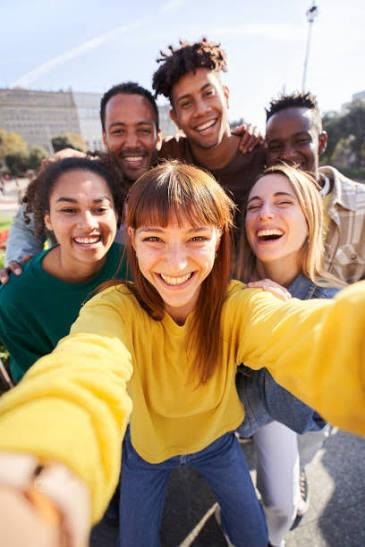

[]

In [3]:
image_path = detections[0]['image_path']
image = load_image(image_path)
w, h = image.size
execute_detection(image_path, detector=llm_detector, visualize=True)

In [4]:
# image = load_image(detections[0]['image_path'])
# # boxes = [det['box'] for det in detections[0]['detections']]
# box_inputs = detections[0]['detections']
# # config.models['sam']['name'] = "facebook/sam2.1-hiera-small"  # Ensure the correct model name is set in the config
# config.models['sam']['name'] = "facebook/sam3"  # Ensure the correct model name is set in the config

# segmented_image = sam_segmenter.segment_with_boxes(image, box_inputs)
# # Pass your image and target coordinates to get list of separate images
# cutout_images = sam_segmenter.extract_segmented_parts(image, box_inputs)

In [ ]:
image = load_image(detections[0]['image_path'])
# boxes = [det['box'] for det in detections[0]['detections']]
box_inputs = detections[0]['detections']
# config.models['sam']['name'] = "facebook/sam2.1-hiera-small"  # Ensure the correct model name is set in the config
config.models['sam']['name'] = "facebook/sam3"  # Ensure the correct model name is set in the config

segmented_image = sam_segmenter.segment_with_concepts(image, ['yellow shirt'])

[2026-07-23 11:18:52] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 11:18:52] [INFO] [fashion_detector:logging.py:98] - Starting: sam3_concept_segmentation
[2026-07-23 11:18:52] [INFO] [fashion_detector:sam3_segmenter.py:172] - Loading SAM 3 model: facebook/sam3 on device: mps


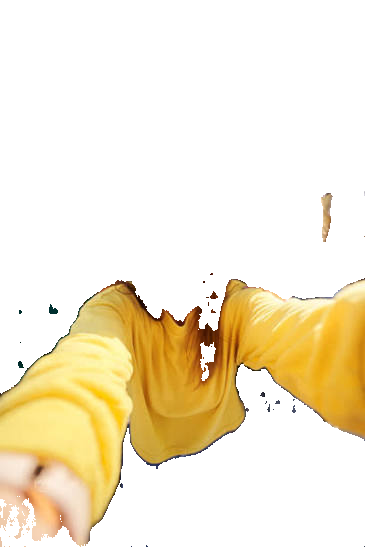

In [ ]:
# display_imageGrid(cutout_images, imgs_per_row=4)
segmented_image